# From Darcy to Buckingham — Part 1: Darcy's Experiment

**MOOC "The Hydrology of Soil" — Chapter 3 (first half)**

---

Chapter 3 explains **how water moves through soil**. It starts where the
subject historically started: with **Henry Darcy's 1856 experiment** in Dijon,
a column of saturated sand with water forced through it.

This notebook lets students:

1. *run* a virtual Darcy column — change the head difference, the column
   length, the sand — and measure the flow;
2. discover **Darcy's law** $q = -K\,\nabla h$ as the straight line through
   the measurements;
3. see what the **saturated hydraulic conductivity** $K_s$ is, how it relates
   to the **intrinsic permeability** $k$, and how it ranges over ~13 orders of
   magnitude across geological materials.

Part 2 then takes the step from **saturated** to **unsaturated** flow — the
move from Darcy to Buckingham.

Run the cells in order (Shift+Enter). Plain NumPy — no special packages.


## 0 — Setup

Run this cell first. It loads the functions hidden inside the course package.

In [1]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")

  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-dftsadl6
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-dftsadl6
  Resolved https://github.com/panzerotto/soil_course.git to commit 5f1ffd0d4b4bfa5da1eae91874e3723b4c4f094b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=15864 sha256=a6745a6421d32605382b99b77df95dd48bfbbb1607afb095ce83d8379fe56d64
  Stored in directory: /tmp/pip-ephem-wheel-cache-6p2osizb/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


## 1 — Darcy's column

Darcy's apparatus is a cylinder of cross-sectional area $A$ packed with
saturated sand of length $L$. Water enters the top at hydraulic head $h_1$ and
leaves the bottom at $h_2$. He measured the **volumetric flow rate** $Q$ and
found it obeyed

$$Q \;=\; K\,A\,\frac{h_1 - h_2}{L},$$

or, per unit area, in terms of the **specific discharge** $q = Q/A$,

$$q \;=\; -K\,\frac{\Delta h}{L} \;=\; -K\,\nabla h.$$

$K$ is the **saturated hydraulic conductivity** [m/s]; the minus sign says
water flows from high head to low head.


In [2]:
# A quick example: 0.5 m of head across a 1 m sand column
q, Q = darcy_example(delta_h=0.5, L=1.0, K=1e-4, A=0.01)

head gradient        = 0.500  (dimensionless)
specific discharge q = 5.000e-05 m/s   ( 4320.0 mm/day )
flow rate Q          = 5.000e-07 m3/s


## 2 — The virtual experiment

The cell below *runs Darcy's experiment*: it imposes a series of head
differences on the column, "measures" the resulting discharge (with a little
random scatter, as a real experiment would have), and plots discharge against
head gradient. The points fall on a straight line — **that line is Darcy's
law**, and its slope is $K$.


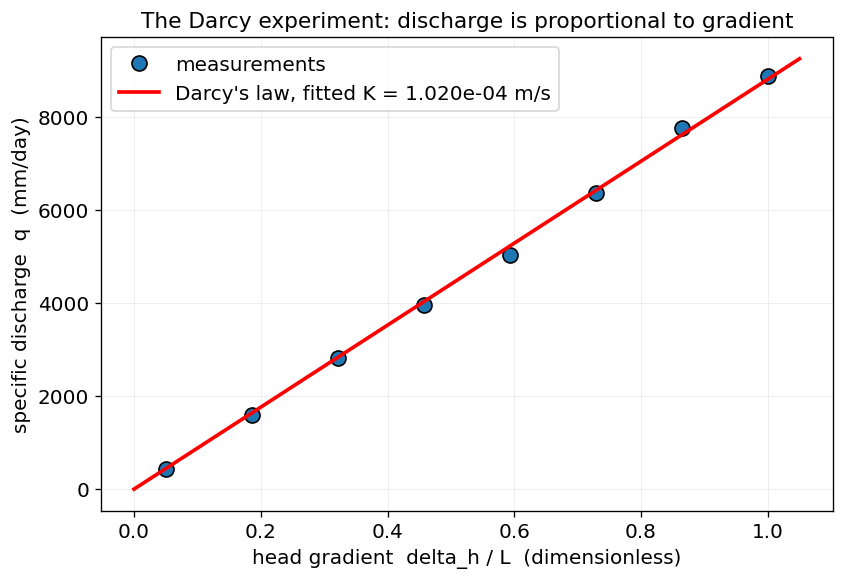

true  K = 1.000e-04 m/s
fitted K = 1.020e-04 m/s   (error +2.0 %)


In [3]:
# Run the virtual Darcy experiment
K_fit = run_darcy_experiment(K_true=1e-4)

The proportionality between discharge and gradient is the **entire
empirical content** of Darcy's law. Everything else in Chapter 3 — unsaturated
flow, Richards' equation — is built on top of this single linear relation.


## 3 — Interactive: change the column

Move the controls and watch the experiment re-run. Note that the **soil**
(through $K$) sets the slope; the column length and area do **not** change $K$
— they only change the flow rate $Q$.

> The slider code is hidden inside the package. If sliders do not appear, call `run_darcy_experiment(...)` directly.


In [4]:
interactive_darcy_experiment()

interactive(children=(Dropdown(description='soil', index=2, options=('gravel', 'coarse sand', 'fine sand', 'si…

interactive(children=(Dropdown(description='soil', index=2, options=('gravel', 'coarse sand', 'fine sand', 'si…

## 4 — Conductivity vs permeability

$K$ mixes together a property of the **medium** and a property of the
**fluid**. Separating them:

$$K \;=\; \frac{k\,\rho_w\,g}{\mu},$$

where $k$ is the **intrinsic permeability** [m²] — a property of the pore
geometry *alone* — and $\rho_w, \mu$ are the density and viscosity of the
fluid. The same soil invaded by a more viscous fluid has a lower $K$ but the
same $k$.


In [5]:
print_permeability_table()

material           K (m/s)        k (m2)     k (darcy)
gravel             1.0e-02      1.02e-09      1.03e+03
coarse sand        1.0e-03      1.02e-10      1.03e+02
fine sand          1.0e-04      1.02e-11      1.03e+01
silt               1.0e-06      1.02e-13      1.03e-01
clay               1.0e-09      1.02e-16      1.03e-04


The conductivity of clay and of gravel differ by **seven orders of
magnitude** — and across all geological materials the range of $K$ spans about
**thirteen** orders of magnitude, one of the widest ranges of any physical
property in the earth sciences.


## 5 — The 13-orders-of-magnitude chart

A visual sense of that range.


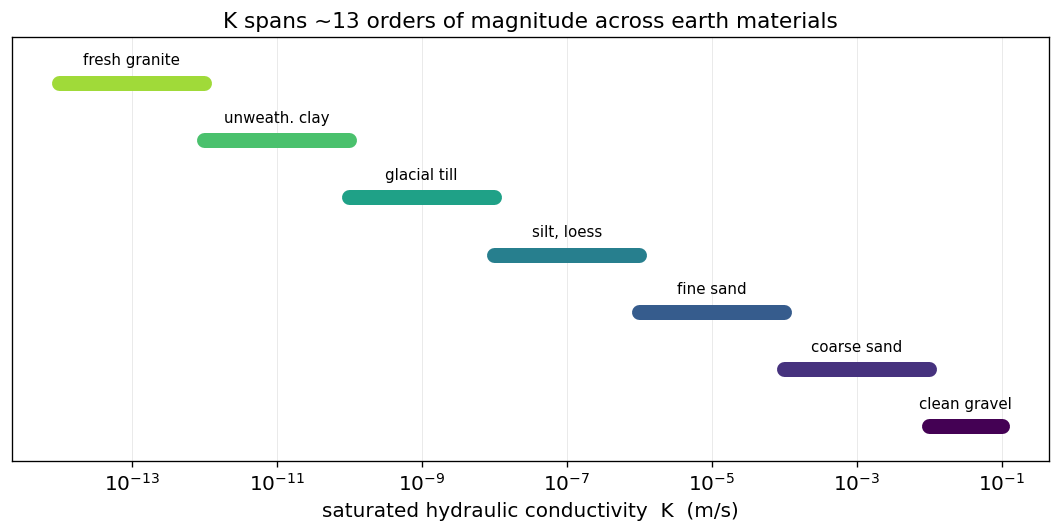

In [6]:
conductivity_chart()

## Exercises

1. **Slope is the soil.** In Section 3, run the experiment for fine sand and
   then for silt. Which property of the plot changes — the slope, the
   intercept, or the scatter? What does that tell you about what $K$ measures?

2. **Length and area.** Using `darcy_flow`, double the column length $L$ with
   everything else fixed. What happens to the specific discharge $q$? Now
   double the area $A$ — what happens to $Q$, and what happens to $q$?

3. **Same pores, different fluid.** A soil has $k = 10^{-12}$ m². Compute its
   $K$ for water, then for a fluid ten times more viscous. Does $k$ change?
   Does $K$?

4. **Reading the chart.** From Section 5, estimate how much longer water takes
   to cross one metre of unweathered clay than one metre of coarse sand, under
   the same head gradient.

5. **The limits of the line.** Darcy's law is linear. Suggest one physical
   situation (think of very high flow velocities, or very low ones) in which
   you might expect the discharge to *stop* being proportional to the gradient.

---

*Companion to the MOOC "The Hydrology of Soil", Chapter 3 (Part 1) —
Darcy's experiment and saturated conductivity. Licensed CC BY-SA, consistent
with the lecture slides.*


## Optional helper cells for the exercises

Use these cells if you want to check calculations while answering the questions above.

In [ ]:
# Exercise 2 helper: change L and A
q1, Q1 = darcy_flow(delta_h=0.5, L=1.0, K=1e-4, A=0.01)
q2, Q2 = darcy_flow(delta_h=0.5, L=2.0, K=1e-4, A=0.01)
q3, Q3 = darcy_flow(delta_h=0.5, L=1.0, K=1e-4, A=0.02)

print("Original:        q =", q1, "Q =", Q1)
print("Double length:   q =", q2, "Q =", Q2)
print("Double area:     q =", q3, "Q =", Q3)

In [ ]:
# Exercise 3 helper: same pores, different fluid
compare_fluid_viscosity(k=1e-12, viscosity_factor=10)